<a href="https://colab.research.google.com/github/GayatriVidhate23/Machine--Vision-Practical/blob/main/MV_PRC_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from google.colab import files

uploaded = files.upload()

Saving prc-04.png to prc-04.png


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

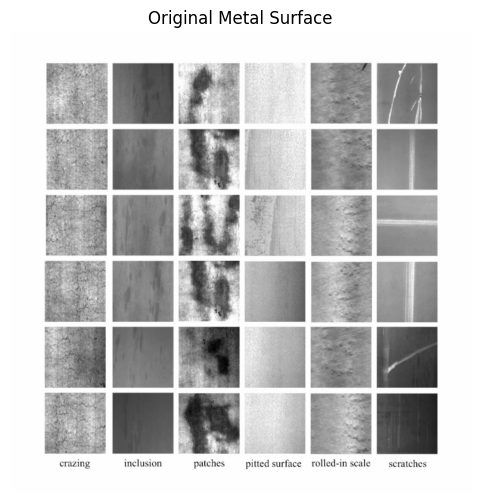

In [19]:
image = cv2.imread(list(uploaded.keys())[0])

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Original Metal Surface")
plt.axis("off")
plt.show()

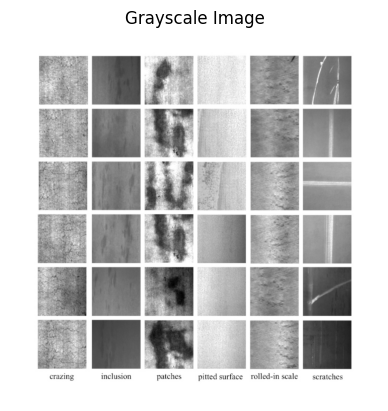

In [20]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

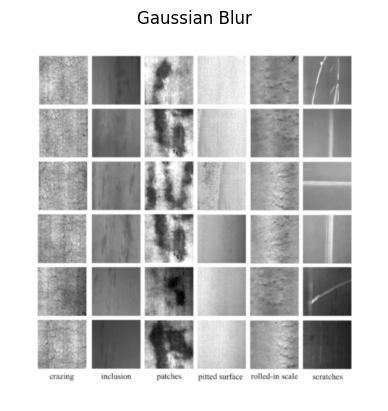

In [21]:
blur = cv2.GaussianBlur(gray,(5,5),0)

plt.imshow(blur,cmap='gray')
plt.title("Gaussian Blur")
plt.axis("off")
plt.show()

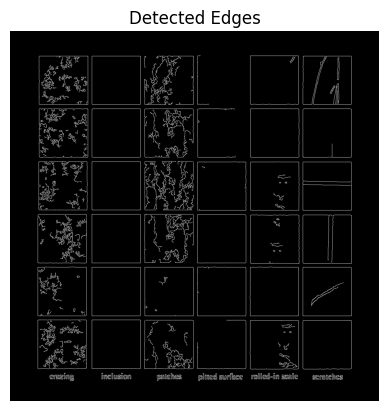

In [22]:
edges = cv2.Canny(blur,50,150)

plt.imshow(edges,cmap='gray')
plt.title("Detected Edges")
plt.axis("off")
plt.show()

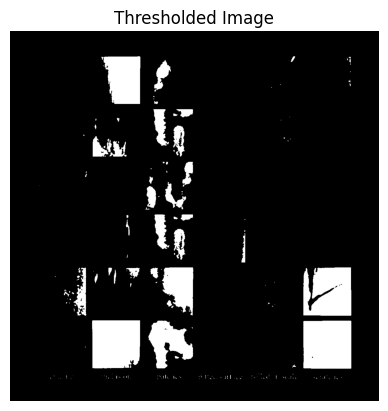

In [24]:
_, thresh = cv2.threshold(
    blur,
    100,
    255,
    cv2.THRESH_BINARY_INV
)

plt.imshow(thresh,cmap='gray')
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

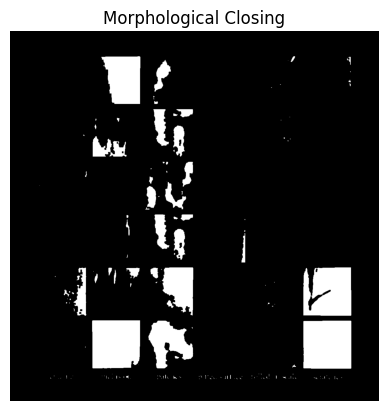

In [25]:
kernel = np.ones((3,3),np.uint8)

morph = cv2.morphologyEx(
    thresh,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

plt.imshow(morph,cmap='gray')
plt.title("Morphological Closing")
plt.axis("off")
plt.show()

In [26]:
contours,_ = cv2.findContours(
    morph,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = image.copy()

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 50:

        x,y,w,h = cv2.boundingRect(cnt)

        cv2.rectangle(
            output,
            (x,y),
            (x+w,y+h),
            (0,255,0),
            2
        )

        cv2.putText(
            output,
            "Defect",
            (x,y-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255,0,0),
            2
        )

print("Number of Defects Detected:",len(contours))

Number of Defects Detected: 162


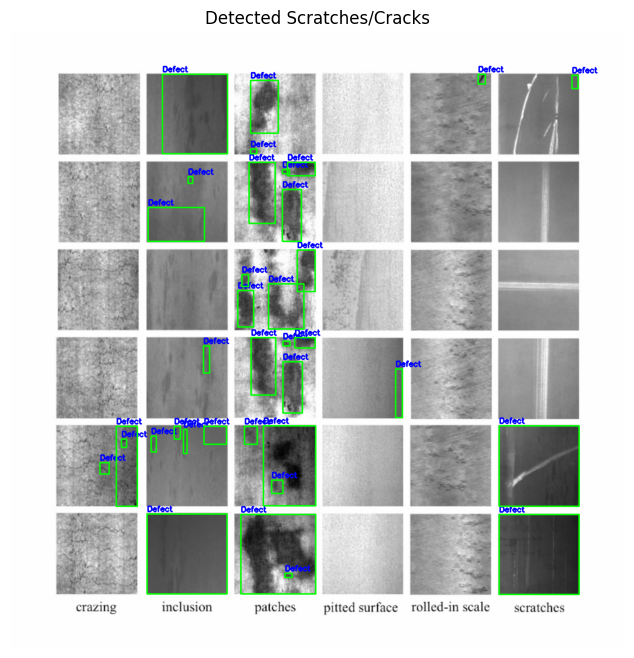

In [27]:
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(output,cv2.COLOR_BGR2RGB))
plt.title("Detected Scratches/Cracks")
plt.axis("off")
plt.show()

In [28]:
cv2.imwrite("Detected_Defects.jpg",output)

from google.colab import files
files.download("Detected_Defects.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>